uni_section_v8: command_v8.md 수정 + /synod design 세션(synod-20260710-095643-81f265) 설계 결정 통합
  - 3.1 custom autograd Function 제거 -> native autograd로 dMp/dt 복원 (+ 유한차분 검증 게이트)
  - 3.2 파트쌍별 collision margin 자동 산정 (고정쌍 0.6mm 간극 -> 만족 가능한 margin)
  - 3.3 mass loss: 초기 단면적 target + sigmoid 게이트 (Mp err<5%에서만 활성)
  - 3.4 leaky tanh 두께 헤드 + L_sat 포화 페널티 + delta_t 포화 모니터링
  - 4   T_MAX 3.0->4.0mm, w_anchor 0.05->0.02 | E1 grad clip 5.0 | E2 300 epochs | E3 best-Mp 체크포인트

데이터: nodes=torch.Size([93, 8]) | edges=torch.Size([2, 176])
[gradcheck] dMp/dt OK -- autograd=1.3173e+07, FD=1.3160e+07, rel_err=9.88e-04, dMp/dt>0 확인
[mass] target_area = 1157.3 mm² (초기 단면적 스냅샷)
[collision] 파트쌍별 margin (초기 clearance 기반 자동 산정):
    sec0 Part0-Part2: margin = 2.00 mm
    sec0 Part2-Part1: margin = 1.28 mm
    sec0 Part1-Part3: margin = 0.75 mm
    sec0 Part3-Part4: margin = 2.00 mm

[ uni_section_v8 ] Training  |  Target Mp = 47,421,470 N·mm  |  Epochs: 300
  CGDN: hidden=128, layers=4, heads=4  |  Curriculum: Tru

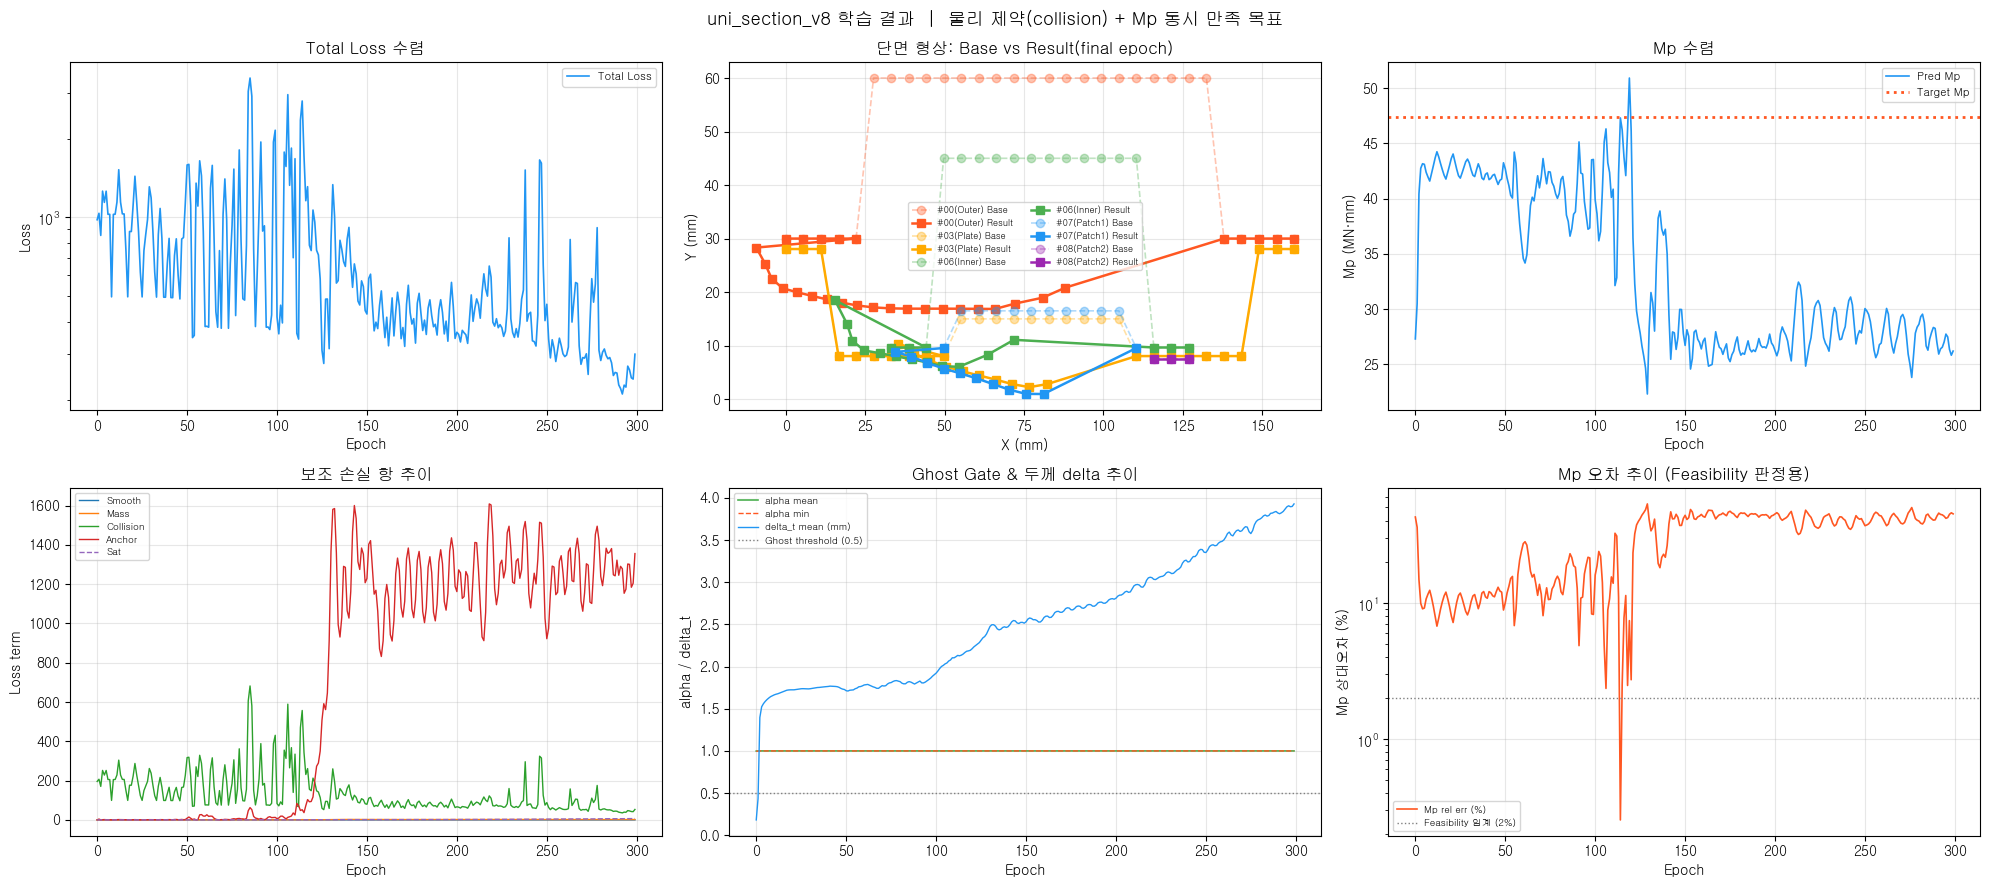


결과 저장: c:\Users\user\Documents\GitHub\hmc_mlv\CGNN\uni-section\uni_section_v8_result.png

최종 결과 요약 (마지막 epoch 기준)
  Target Mp     :     47,421,470 N·mm
  Final pred_mp :     26,197,624 N·mm
  Final Error   :  44.76%
  Final l_collision : 53.2316
  Final alpha   : mean=1.000 / min=1.000
  Final delta_t : mean=+3.929 mm

  ⚠ Feasible 모델을 찾지 못함 — best-Mp 체크포인트(epoch 114, err 0.25%)를 참고해 원인 분석 필요.


In [1]:
#!/usr/bin/env python
# coding: utf-8

"""
uni_section_v8.py
─────────────────────────────────────
uni_section_v7.py의 Mp 미수렴 문제를 docs/command_v8.md 지시 사항 +
/synod design 세션(synod-20260710-095643-81f265, Gemini flash/high + OpenAI o3/high
실제 병렬 교차검증, conf 98%/92%, 조기 합의)에서 도출된 설계 결정을 반영해 재작성한 버전.

목표(사용자 명시): 단일 섹션 B-Pillar 구조가 "물리적 제약(파트 간 침투 방지)을 만족하면서
목표 전소성 모멘트(target Mp)를 동시에 만족"시키는 것.

docs/command_v8.md 반영 사항:
  §3.1 [최우선] 두께 gradient 복원 — /synod 합의(Gemini 안 채택): custom autograd Function
       (ImplicitPNASolver)을 완전히 제거. Envelope Theorem에 의해 평형점에서
       ∂Mp/∂y_pna = -g(y_pna) = 0 이므로, y_pna를 no_grad로 풀어 detach한 뒤 Mp를
       미분 가능한 연산으로 계산하면 native autograd가 coords와 t 양쪽에 대해
       "수학적으로 정확한" gradient를 자동 산출한다. v7의 compute_edge_mp_pna가 이미
       이 구조였으므로 custom Function 래퍼를 벗겨내는 것이 최소 변경이자 근본 해결.
       + 학습 시작 전 유한차분(central difference)으로 dMp/dt > 0 및 상대오차 < 1e-3 검증.
  §3.2 collision margin 기하 정합 — /synod 합의(OpenAI 안 채택): 파트쌍별 margin.
       초기 형상에서 인접 파트쌍의 최소 이격(clearance)을 측정해
       margin_pair = min(2.0, max(0.3, 0.8 × clearance)) 로 자동 설정.
       → Part1–Part4 고정쌍(초기 이격 0.6mm)은 margin ≈ 0.48mm가 되어 만족 가능해지고,
         나머지 쌍은 2.0mm 안전 여유 유지.
  §3.3 mass loss 재정식화 — target_area = 초기 단면적 스냅샷, l_mass = ((A-A0)/A0)^2.
       /synod 합의(Gemini 안 채택): sigmoid(10×(0.05 - MpErr)) 연속 게이트 —
       Mp 오차가 5% 안으로 들어와야 mass 항이 활성화 (조기 박육화 방지).
  §3.4 포화 세이프가드 — leaky tanh(0.95·tanh(x) + 0.05·x/3)로 두께 헤드 gradient 하한 확보,
       L_sat = relu(|delta_t| - 1.35)^2 (w=0.01) 소프트 복귀 페널티,
       delta_t 포화 파트 수 모니터링(alpha 기준보다 조기 경보).
  §3.5 커리큘럼 유지 — collision 항상 1.0, phys 0.2→1.0 sine ramp, dual-threshold
       feasibility checkpointing(Mp err<2% AND collision<0.05) 유지.
  §4   도달 가능성 — T_MAX 3.0→4.0mm(설계 공간 +33%), w_anchor 0.05→0.02(좌표 자유도 확대).

/synod design 세션 추가 결정 (OpenAI 제안 채택):
  E1 grad clip 5.0 — 두께 gradient가 "처음으로" 흐르기 시작할 때의 급격한 점프 방지.
  E2 max_epochs 250→300 — 두께·좌표 동시 최적화 여유 확보.
  E3 best-feasible 체크포인트 외에 best-Mp(collision 무관) 체크포인트도 별도 저장 —
     학습 말기 collision 스파이크에 갇히는 것 방지.

v7과 동일하게 유지되는 부분:
  - CGDN(GATv2+FiLM) 백본, build_bpillar_section() 초기 좌표·fix point·엣지 구성
  - l_phys = sqrt(상대 Mp 오차), 인접쌍(i,i+1) collision 검사, soft(logit-sigmoid) 두께 clamp
  - alpha(Ghost Gate)는 collision 가중 전용(detach) — §3.1로 phys 경로가 열렸으므로 유지
"""

import math
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Gulim'  # Windows 한글 폰트

from torch_geometric.nn import GATv2Conv, LayerNorm
from torch_geometric.data import Data


# ══════════════════════════════════════════════════════════════════
# SECTION 0: Mp 계산 — native autograd (command_v8.md §3.1)
#   custom autograd Function(ImplicitPNASolver) 제거.
#   y_pna 이분탐색은 no_grad(=detach)로 수행하고, Mp는 미분 가능 연산으로 계산.
#   Envelope Theorem: 평형점에서 ∂Mp/∂y_pna = 0 이므로 y_pna 고정 하 직접 미분이
#   전미분과 일치 → coords/t 모두 정확한 gradient가 native autograd로 흐른다.
# ══════════════════════════════════════════════════════════════════

def compute_edge_mp_pna(coords, t, fy, edge_index, n_iter=50):
    """
    Thick Edge (2D Plate) PNA 이분탐색 + Mp 계산.
    v7과 수식 동일. v8에서는 이 함수를 직접 호출해 native autograd로
    ∂Mp/∂coords, ∂Mp/∂t 를 모두 얻는다 (§3.1).
    Returns: (mp_total, y_pna)
    """
    mask = edge_index[0] < edge_index[1]
    u, v = edge_index[0][mask], edge_index[1][mask]

    y_u, y_v = coords[u, 1], coords[v, 1]
    x_u, x_v = coords[u, 0], coords[v, 0]
    L = torch.sqrt((x_u - x_v) ** 2 + (y_u - y_v) ** 2)
    t_e  = t[u].squeeze(-1)
    fy_e = fy[u].squeeze(-1)

    dx   = torch.abs(x_u - x_v)
    t_y  = t_e * (dx / (L + 1e-12))
    y_max = torch.maximum(y_u, y_v)
    y_min = torch.minimum(y_u, y_v)
    y_top = y_max + t_y / 2.0
    y_bot = y_min - t_y / 2.0
    H     = torch.clamp(y_top - y_bot, min=1e-12)

    Area_fy = L * t_e * fy_e

    # ── y_pna 이분탐색: 평형 조건의 해 → detach (Envelope Theorem 적용점) ──
    with torch.no_grad():
        y_lo = coords[:, 1].min().clone() - 5.0
        y_hi = coords[:, 1].max().clone() + 5.0
        for _ in range(n_iter):
            y_mid = 0.5 * (y_lo + y_hi)
            alpha = torch.clamp((y_top - y_mid) / H, 0.0, 1.0)
            net_force = torch.sum(Area_fy * (2.0 * alpha - 1.0))
            if net_force > 0:
                y_lo = y_mid
            else:
                y_hi = y_mid
        y_pna = 0.5 * (y_lo + y_hi)

    # ── Mp: y_pna 고정 하 미분 가능 연산 — grad가 coords와 t 모두로 흐름 ──
    alpha        = torch.clamp((y_top - y_pna) / H, 0.0, 1.0)
    centroid_top = y_top - (alpha * H) / 2.0
    centroid_bot = y_bot + ((1.0 - alpha) * H) / 2.0
    m_top        = alpha * (centroid_top - y_pna)
    m_bot        = (1.0 - alpha) * (y_pna - centroid_bot)
    mp_total     = torch.sum(Area_fy * (m_top + m_bot))

    return mp_total, y_pna


def calculate_mpl(coords, t, fy, edge_index):
    """v7의 ImplicitPNASolver.apply 대체 — native autograd 직접 사용 (§3.1)"""
    mp_total, _ = compute_edge_mp_pna(coords, t, fy, edge_index)
    return mp_total


def verify_thickness_gradient(coords, t, fy, edge_index, eps=1e-4):
    """
    [command_v8.md §3.1 검증 필수] 학습 시작 전 유한차분으로 ∂Mp/∂t 검증.
      1) autograd gradient가 None이 아니고
      2) 균일 섭동 방향 유한차분과 상대오차 < 1e-3
      3) dMp/dt > 0 (두께 증가 → Mp 증가)
    실패 시 RuntimeError로 학습을 중단시킨다 (v7 재발 방지).
    """
    coords = coords.detach()
    fy = fy.detach()

    t_leaf = t.detach().clone().requires_grad_(True)
    mp, _ = compute_edge_mp_pna(coords, t_leaf, fy, edge_index)
    mp.backward()
    if t_leaf.grad is None:
        raise RuntimeError("[gradcheck] dMp/dt 가 None -- 3.1 수정이 적용되지 않음!")
    grad_sum = t_leaf.grad.sum().item()  # 균일 섭동 방향 방향미분 = grad 합

    with torch.no_grad():
        mp_p, _ = compute_edge_mp_pna(coords, t + eps, fy, edge_index)
        mp_m, _ = compute_edge_mp_pna(coords, t - eps, fy, edge_index)
    fd = (mp_p.item() - mp_m.item()) / (2.0 * eps)

    rel_err = abs(fd - grad_sum) / (abs(fd) + 1e-8)
    if fd <= 0:
        raise RuntimeError(f"[gradcheck] dMp/dt = {fd:.4e} <= 0 -- 물리적으로 비정상!")
    if rel_err > 1e-3:
        raise RuntimeError(f"[gradcheck] autograd({grad_sum:.6e}) vs FD({fd:.6e}) "
                           f"상대오차 {rel_err:.2e} > 1e-3")
    print(f"[gradcheck] dMp/dt OK -- autograd={grad_sum:.4e}, FD={fd:.4e}, "
          f"rel_err={rel_err:.2e}, dMp/dt>0 확인")
    return grad_sum, fd, rel_err


class FiLMGenerator(nn.Module):
    """target_mp [B, 1] → (gamma, beta) [B, hidden]"""
    MP_SCALE = 1e6

    def __init__(self, hidden_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.GELU(),
            nn.Linear(64, hidden_channels * 2),
        )
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, target_mp):
        target_mp_norm = target_mp / self.MP_SCALE
        out = self.net(target_mp_norm)
        delta_gamma, beta = torch.chunk(out, 2, dim=-1)
        gamma = 1.0 + delta_gamma
        return gamma, beta


class CGDNBlock(nn.Module):
    """GATv2Conv → LayerNorm → FiLM modulation → GELU → Residual  (AdaIN pattern)"""
    def __init__(self, hidden_channels: int, heads: int = 4, edge_dim: int = 4):
        super().__init__()
        assert hidden_channels % heads == 0
        self.conv = GATv2Conv(
            hidden_channels,
            hidden_channels // heads,
            heads=heads,
            edge_dim=edge_dim,
            concat=True,
        )
        self.norm = LayerNorm(hidden_channels)

    def forward(self, h, edge_index, edge_attr, gamma, beta):
        h_res = h
        h = self.conv(h, edge_index, edge_attr)
        h = self.norm(h)
        h = gamma * h + beta
        h = F.gelu(h)
        h = h + h_res
        return h


class CGDN(nn.Module):
    """
    Constraint-aware Graph Deformation Network v8
    [command_v8.md §3.4] leaky tanh 두께 헤드 + [§4] T_MAX 4.0mm.

    입력 노드 특징 (in_channels=8): [x, y, fix_x, fix_y, part_id, section_id, t, fy]
    엣지 특징 (edge_dim=4): [길이, 각도, part_id, edge_type]

    forward() 반환값: (new_coords, delta_coords, t_final, alpha, delta_t_part)
      - t_final: 순수 두께 예측값 (alpha 무관 — v7 §2.1 유지). §3.1로 phys loss가
        이 값을 직접 밀어올릴 수 있게 됨.
      - alpha  : Ghost Gate (collision 가중 전용, detach 사용처에서)
      - delta_t_part: 포화 모니터링/L_sat 용
    """

    GHOST_THRESHOLD = 0.5   # mm — alpha=0.5 전환점
    GHOST_STEEPNESS = 5.0   # v7 유지
    DELTA_SCALE     = 1.5   # ±1.5mm — 두께 변화 최대폭 (leaky로 약간 초과 가능)
    T_MIN           = 0.1   # mm
    T_MAX           = 4.0   # mm — [command_v8.md §4] 3.0 → 4.0 설계 공간 확대

    def __init__(
        self,
        in_channels: int = 8,
        hidden_channels: int = 128,
        num_layers: int = 4,
        heads: int = 4,
        edge_dim: int = 4,
        max_displacement: float = 50.0,
    ):
        super().__init__()
        self.max_displacement = max_displacement
        self.num_layers = num_layers

        self.node_encoder = nn.Sequential(
            nn.Linear(in_channels, hidden_channels),
            LayerNorm(hidden_channels),
            nn.GELU(),
        )
        self.film_generators = nn.ModuleList([
            FiLMGenerator(hidden_channels) for _ in range(num_layers)
        ])
        self.blocks = nn.ModuleList([
            CGDNBlock(hidden_channels, heads=heads, edge_dim=edge_dim)
            for _ in range(num_layers)
        ])

        # 좌표 헤드
        self.coord_decoder = nn.Sequential(
            nn.Linear(hidden_channels, 64),
            nn.GELU(),
            nn.Linear(64, 2),
        )

        # 두께 헤드 — [§3.4] Tanh 레이어 제거, raw 출력에 leaky tanh 적용
        self.thickness_decoder = nn.Sequential(
            nn.Linear(hidden_channels, 32),
            nn.GELU(),
            nn.Linear(32, 1),
        )
        # 양(+) bias 초기화: 초기 delta_t 약간 양수 → active 상태로 시작
        nn.init.constant_(self.thickness_decoder[-1].bias, 0.07)

    @staticmethod
    def leaky_tanh(x):
        """[command_v8.md §3.4] 0.95·tanh(x) + 0.05·x/3 — gradient 하한 ≈ 0.017 확보"""
        return 0.95 * torch.tanh(x) + 0.05 * x / 3.0

    def forward(self, x, edge_index, edge_attr, target_mp,
                fix_x_mask, fix_y_mask, join_pairs=None):
        h = self.node_encoder(x)

        for i, block in enumerate(self.blocks):
            gamma, beta = self.film_generators[i](target_mp)
            h = block(h, edge_index, edge_attr, gamma, beta)

        # ── 좌표 예측 ──
        delta_coords = self.coord_decoder(h)
        delta_coords = torch.clamp(delta_coords, -self.max_displacement, self.max_displacement)
        delta_x = delta_coords[:, 0:1] * (~fix_x_mask).float()
        delta_y = delta_coords[:, 1:2] * (~fix_y_mask).float()
        delta_coords = torch.cat([delta_x, delta_y], dim=1)
        new_coords = x[:, :2] + delta_coords

        if join_pairs is not None and join_pairs.shape[0] > 0:
            u_idx = join_pairs[:, 0]
            v_idx = join_pairs[:, 1]
            mid = (new_coords[u_idx] + new_coords[v_idx]) * 0.5
            new_coords = new_coords.clone()
            new_coords[u_idx] = mid
            new_coords[v_idx] = mid

        # ── 두께 예측: leaky tanh (§3.4) ──
        delta_t_raw = self.thickness_decoder(h)               # [N, 1], unbounded
        delta_t_raw = self.leaky_tanh(delta_t_raw) * self.DELTA_SCALE

        # Part-level 단일 두께 강제 (제조 제약) — scatter 방식
        part_ids_local    = x[:, 4].long()
        section_ids_local = x[:, 5].long()
        t_initial         = x[:, 6].unsqueeze(1)

        max_parts = int(part_ids_local.max().item()) + 1
        composite_key = section_ids_local * max_parts + part_ids_local
        _, inverse = torch.unique(composite_key, return_inverse=True)
        num_groups = int(inverse.max().item()) + 1

        delta_t_1d  = delta_t_raw.squeeze(-1)
        group_sum   = torch.zeros(num_groups, device=x.device).scatter_add_(0, inverse, delta_t_1d)
        group_count = torch.zeros(num_groups, device=x.device).scatter_add_(0, inverse, torch.ones_like(delta_t_1d))
        group_mean  = group_sum / group_count.clamp(min=1)
        delta_t_part = group_mean[inverse].unsqueeze(-1)

        # Soft clamp (v7 §2.3 유지, T_MAX만 4.0): 로짓-시그모이드 매핑
        t_min, t_max = self.T_MIN, self.T_MAX
        t_initial_frac = (t_initial - t_min) / (t_max - t_min)
        t_initial_frac = torch.clamp(t_initial_frac, 1e-4, 1.0 - 1e-4)
        t_initial_logit = torch.logit(t_initial_frac)
        t_new = t_min + (t_max - t_min) * torch.sigmoid(t_initial_logit + delta_t_part)

        # Ghost Gate — collision masking 전용 (v7 §2.1 유지)
        alpha = torch.sigmoid(self.GHOST_STEEPNESS * (t_new - self.GHOST_THRESHOLD))

        t_final = t_new

        return new_coords, delta_coords, t_final, alpha, delta_t_part


# ══════════════════════════════════════════════════════════════════
# SECTION 1: Loss Functions
# ══════════════════════════════════════════════════════════════════

def compute_smoothness_loss_angle(new_coords, edge_index, edge_attr):
    """현재 각도만 고려해 노드별 좌우 엣지 각도 최소화 & 90도 미만 제한 (v7 동일)"""
    src, dst = edge_index
    edge_type = edge_attr[:, 3]

    mask = (src < dst) & torch.isclose(edge_type, torch.zeros_like(edge_type))
    if not mask.any():
        return torch.tensor(0.0, device=new_coords.device)

    src = src[mask]
    dst = dst[mask]

    num_nodes = new_coords.shape[0]
    all_u = torch.cat([src, dst])
    all_v = torch.cat([dst, src])

    adj = [[] for _ in range(num_nodes)]
    for u, v in zip(all_u.tolist(), all_v.tolist()):
        adj[u].append(v)

    left_angles = []
    right_angles = []

    for node, neighbors in enumerate(adj):
        if len(neighbors) < 2:
            continue

        node_x = new_coords[node, 0]
        left_nodes = [n for n in neighbors if new_coords[n, 0] < node_x]
        right_nodes = [n for n in neighbors if new_coords[n, 0] > node_x]

        if len(left_nodes) != 1 or len(right_nodes) != 1:
            continue

        left_node = left_nodes[0]
        right_node = right_nodes[0]

        left_vec = new_coords[node] - new_coords[left_node]
        right_vec = new_coords[right_node] - new_coords[node]

        left_angles.append(torch.atan2(left_vec[1], left_vec[0]))
        right_angles.append(torch.atan2(right_vec[1], right_vec[0]))

    if len(left_angles) == 0:
        return torch.tensor(0.0, device=new_coords.device)

    left_angles = torch.stack(left_angles)
    right_angles = torch.stack(right_angles)

    results = 0.0

    angle_diff = (left_angles - right_angles + math.pi) % (2.0 * math.pi) - math.pi
    results += torch.mean(angle_diff.pow(2))

    max_rad = math.pi / 2.0
    left_violation = torch.relu(left_angles.abs() - max_rad)
    right_violation = torch.relu(right_angles.abs() - max_rad)
    results += torch.mean(left_violation.pow(2) + right_violation.pow(2))

    return results


def compute_mass_loss_v8(new_coords, t, edge_index, edge_attr, target_area):
    """
    [command_v8.md §3.3] target 기반 mass loss: l_mass = ((A - A0)/A0)^2.
    v7의 무목표 축소 압력(area*1e-6) 제거 — target_area는 필수(초기 단면적 스냅샷).
    """
    src, dst = edge_index
    edge_type = edge_attr[:, 3]

    mask = (src < dst) & torch.isclose(edge_type, torch.zeros_like(edge_type))
    src = src[mask]
    dst = dst[mask]

    seg_len = torch.norm(new_coords[src] - new_coords[dst], dim=1)
    t_src = t[src].squeeze(-1)
    area = torch.sum(seg_len * t_src)

    l_mass = ((area - target_area) / (target_area + 1e-12)) ** 2
    return area, l_mass


def compute_anchor_loss(new_coords, base_coords, fix_x_mask, fix_y_mask):
    """좌표 anchor 정규화 (L2, v7 D2 유지 — 가중치는 §4에 따라 0.05→0.02로 완화)"""
    disp = new_coords - base_coords
    return torch.mean(disp[:, 0] ** 2 + disp[:, 1] ** 2)


def compute_saturation_loss(delta_t_part, delta_scale=1.5, knee=0.9):
    """
    [command_v8.md §3.4] L_sat = relu(|delta_t| - knee×scale)^2.
    |delta_t|가 1.35mm(=0.9×1.5)를 넘을 때만 발동해 tanh 벽에 닿기 전에 부드럽게 되돌림.
    """
    threshold = knee * delta_scale
    return torch.mean(torch.relu(delta_t_part.abs() - threshold) ** 2)


def _compute_segment_penetration_loss(coords_outer, coords_inner, normal_direction_CW, margin):
    """엣지 세그먼트 기반 침투 손실 (v7 동일)"""
    if coords_outer.shape[0] < 2 or coords_inner.shape[0] == 0:
        return torch.tensor(0.0, device=coords_outer.device, requires_grad=True)

    A = coords_outer[:-1]
    B = coords_outer[1:]
    AB = B - A

    P = coords_inner.unsqueeze(1)
    A_exp = A.unsqueeze(0)
    AB_exp = AB.unsqueeze(0)

    AB_squared = torch.sum(AB_exp ** 2, dim=-1) + 1e-8
    AP = P - A_exp
    t_proj = torch.sum(AP * AB_exp, dim=-1) / AB_squared

    valid_mask = (t_proj >= 0.0) & (t_proj <= 1.0)
    if valid_mask.sum() == 0:
        return torch.tensor(0.0, device=coords_outer.device, requires_grad=True)

    C = A_exp + t_proj.unsqueeze(-1) * AB_exp

    tangent = AB_exp / (torch.norm(AB_exp, dim=-1, keepdim=True) + 1e-8)
    if normal_direction_CW:
        normal = torch.stack([tangent[..., 1], -tangent[..., 0]], dim=-1)
    else:
        normal = torch.stack([-tangent[..., 1], tangent[..., 0]], dim=-1)

    normal = normal.expand(P.shape[0], -1, -1)

    CP = P - C
    projection = torch.sum(CP * normal, dim=-1)
    violation = torch.relu(margin - projection) * valid_mask.float()

    return torch.sum(violation)


def _min_pair_distance(coords_a, coords_b):
    """두 파트 간 최소 point-to-segment 무부호 거리 (margin 자동 산정용)"""
    def one_way(pts, seg_pts):
        if seg_pts.shape[0] < 2 or pts.shape[0] == 0:
            return float('inf')
        A = seg_pts[:-1]
        B = seg_pts[1:]
        AB = B - A
        P = pts.unsqueeze(1)
        A_exp = A.unsqueeze(0)
        AB_exp = AB.unsqueeze(0)
        AB_sq = torch.sum(AB_exp ** 2, dim=-1) + 1e-8
        t_proj = torch.clamp(torch.sum((P - A_exp) * AB_exp, dim=-1) / AB_sq, 0.0, 1.0)
        C = A_exp + t_proj.unsqueeze(-1) * AB_exp
        d = torch.norm(P - C, dim=-1)
        return d.min().item()

    return min(one_way(coords_a, coords_b), one_way(coords_b, coords_a))


def compute_pair_margins(coords, part_ids, section_ids, parts_order_in_sections,
                          default_margin=2.0, margin_floor=0.3, clearance_ratio=0.8):
    """
    [command_v8.md §3.2] 파트쌍별 collision margin 자동 산정 (/synod OpenAI 안).
    초기 형상에서 인접쌍의 최소 이격(clearance)을 측정해
      margin = min(default, max(floor, ratio × clearance))
    → 고정 노드 때문에 이격이 default보다 작은 쌍(예: Part1–Part4, 0.6mm)은
      만족 가능한 margin(≈0.48mm)으로 자동 완화, 나머지는 2.0mm 유지.
    """
    margins = {}
    with torch.no_grad():
        for sec_key, order in parts_order_in_sections.items():
            sec_mask = (section_ids == sec_key)
            for i in range(len(order) - 1):
                po, pi = order[i], order[i + 1]
                ca = coords[sec_mask & (part_ids == po)]
                cb = coords[sec_mask & (part_ids == pi)]
                clearance = _min_pair_distance(ca, cb)
                m = min(default_margin, max(margin_floor, clearance_ratio * clearance))
                margins[(sec_key, po, pi)] = m
    return margins


def compute_collision_loss_v4_pair_margin(new_coords, part_ids, section_ids, alpha,
                                           pair_margins, parts_order_in_sections):
    """
    Ghost-aware 계층적 침투 방지 손실 — v7의 인접쌍 검사 유지,
    [§3.2] 고정 margin=2 대신 pair_margins 딕셔너리 사용.
    alpha는 detach 사용 (v7 유지 — collision이 두께를 직접 조작하는 trivial solution 차단).
    """
    total_loss = torch.tensor(0.0, device=new_coords.device, requires_grad=True)

    unique_sections = torch.unique(section_ids)
    valid_pairs_count = 0

    for sec in unique_sections:
        sec_int = int(sec.item())
        sec_mask = (section_ids == sec)
        sec_parts = part_ids[sec_mask]

        full_order = torch.tensor(parts_order_in_sections[sec_int], dtype=part_ids.dtype, device=part_ids.device)
        unique_parts = torch.unique(sec_parts)
        ordered_parts = full_order[torch.isin(full_order, unique_parts)]

        if len(ordered_parts) < 2:
            continue

        for i in range(len(ordered_parts) - 1):
            outer_part_id = ordered_parts[i]
            inner_part_id = ordered_parts[i + 1]

            mask_outer = sec_mask & (part_ids == outer_part_id)
            mask_inner = sec_mask & (part_ids == inner_part_id)

            coords_outer = new_coords[mask_outer]
            coords_inner = new_coords[mask_inner]

            margin = pair_margins.get(
                (sec_int, int(outer_part_id.item()), int(inner_part_id.item())), 2.0)

            alpha_o = alpha[mask_outer].mean().detach()
            alpha_i = alpha[mask_inner].mean().detach()
            ghost_weight = alpha_o * alpha_i

            loss_oi = _compute_segment_penetration_loss(coords_outer, coords_inner, True,  margin)
            loss_io = _compute_segment_penetration_loss(coords_inner, coords_outer, False, margin)
            total_loss = total_loss + (loss_oi + loss_io) * ghost_weight
            valid_pairs_count += 1

    if valid_pairs_count > 0:
        total_loss = total_loss / valid_pairs_count

    return total_loss


# ══════════════════════════════════════════════════════════════════
# SECTION 2: 커리큘럼 학습 스케줄러 (v7 D1 유지 — §3.5)
# ══════════════════════════════════════════════════════════════════

def get_curriculum_weights_v8(epoch, total_epochs, curriculum_ratio):
    """
    3-stage curriculum (v7 유지):
      Stage A: s_collision=1.0, s_phys=0.2, s_smooth=s_mass=0.0
      Stage B: s_phys 0.2→1.0 sine ramp, s_smooth/s_mass 0→1 ramp, s_collision=1.0
      Stage C: 전항 1.0 고정 (미세조정)
    """
    stage_a_end = int(total_epochs * curriculum_ratio[0])
    stage_b_end = int(total_epochs * curriculum_ratio[1])

    s_collision = 1.0

    if epoch < stage_a_end:
        progress = 0.0
    elif epoch < stage_b_end:
        x = (epoch - stage_a_end) / max(stage_b_end - stage_a_end, 1)
        progress = 0.5 * (1 + math.sin(math.pi * (x - 0.5)))
    else:
        progress = 1.0

    s_phys   = 0.2 + 0.8 * progress
    s_smooth = progress
    s_mass   = progress

    return s_phys, s_smooth, s_mass, s_collision


# ══════════════════════════════════════════════════════════════════
# SECTION 3: Data Setup  (build_bpillar_section — v7/validate_v9 그대로, 수정 없음)
# ══════════════════════════════════════════════════════════════════

def build_bpillar_section():
    """
    B-Pillar 5-Part 단면 (사용자 제공 도면의 X-비율 완벽 모사)
    initial 좌표 구성은 pna_solver_validate_v9.py 와 100% 동일하게 유지.
    """
    part_configs = [
        (0, 30.0, 2.30, 1470.0, True),   # #00 Outer Hat
        (1, 28.05, 1.60,  980.0, False), # #03 Inner Plate
        (2, 29.0, 1.60, 1470.0, True),   # #06 Inner Hat
        (3, 24.0, 1.40,  980.0, False),  # #07 Patch 1
        (4, 22.0, 1.60,  440.0, False),  # #08 Patch 2
    ]

    num_nodes   = 30
    total_width = 160.0
    dx          = total_width / (num_nodes - 1)

    nodes = []
    node_registry = {}
    idx = 0
    num_nodes_per_part = {}
    eps = 1e-3

    for part_id, y_base, t_val, fy_val, _ in part_configs:
        local_idx = 0
        for i in range(num_nodes):
            x_coord = i * dx
            x_ratio = x_coord / total_width

            if part_id == 2 and (x_ratio < 0.2 - eps or x_ratio > 0.8 + eps):
                continue
            if part_id == 3 and (x_ratio < 0.3 - eps or x_ratio > 0.7 + eps):
                continue
            if part_id == 4 and (x_ratio < 0.7 - eps or x_ratio > 0.8 + eps):
                continue

            fix = 0.0

            if part_id == 0:
                if x_ratio <= 0.1667 + eps or x_ratio >= 0.8333 - eps:
                    fix = 1.0
                    y_coord_node = 30.0
                else:
                    y_coord_node = 60.0

            elif part_id == 1:
                if x_ratio <= 0.0833 + eps or x_ratio >= 0.9167 - eps:
                    fix = 1.0
                    y_coord_node = 28.05
                elif (x_ratio >= 0.0833 + eps and x_ratio < 0.3334 - eps) or (x_ratio > 0.6666 + eps and x_ratio <= 0.9167 - eps):
                    fix = 1.0
                    y_coord_node = 8.05
                elif 0.3334 - eps <= x_ratio <= 0.6666 + eps:
                    y_coord_node = 15.0
                else:
                    y_coord_node = 8.05

            elif part_id == 2:
                if (x_ratio <= 0.3 - eps and x_ratio > 0.2 + eps) or (x_ratio >= 0.7 + eps and x_ratio < 0.8 - eps):
                    fix = 1.0
                    y_coord_node = 9.65
                else:
                    y_coord_node = 45.0

            elif part_id == 3:
                if (x_ratio <= 0.33 - eps and x_ratio > 0.3 + eps) or (x_ratio >= 0.67 + eps and x_ratio < 0.7 - eps):
                    fix = 1.0
                    y_coord_node = 9.55
                else:
                    y_coord_node = 16.5

            elif part_id == 4:
                fix = 1.0
                y_coord_node = 7.45

            nodes.append([x_coord, y_coord_node, fix, fix, float(part_id), 0.0, t_val, fy_val])
            node_registry[(part_id, local_idx)] = idx
            local_idx += 1
            idx += 1

        num_nodes_per_part[part_id] = local_idx

    x = torch.tensor(nodes, dtype=torch.float32)

    src_list, dst_list, edge_attr_list = [], [], []

    def add_edge(u, v, part_id):
        dx_val = x[v, 0] - x[u, 0]
        dy_val = x[v, 1] - x[u, 1]
        length = math.sqrt(dx_val**2 + dy_val**2)
        angle  = math.atan2(dy_val, dx_val)
        src_list.extend([u, v])
        dst_list.extend([v, u])
        edge_attr_list.extend([[length, angle, float(part_id), 0.0],
                               [length, -angle, float(part_id), 0.0]])

    for part_id, _, _, _, _ in part_configs:
        for i in range(num_nodes_per_part[part_id] - 1):
            u = node_registry[(part_id, i)]
            v = node_registry[(part_id, i + 1)]
            add_edge(u, v, part_id)

    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
    edge_attr  = torch.tensor(edge_attr_list, dtype=torch.float32)
    join_pairs = torch.zeros((0, 2), dtype=torch.long)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, join_pairs=join_pairs), node_registry


def compute_y_pna_ref(coords, t, fy, edge_index, n_iter=50):
    """Thick Edge bisection으로 y_pna 계산 (검증용, v7 그대로)"""
    with torch.no_grad():
        _, y_pna = compute_edge_mp_pna(coords, t, fy, edge_index, n_iter)
        return y_pna.item() if torch.is_tensor(y_pna) else y_pna


def compute_section_area(coords, t, edge_index, part_ids=None):
    """단면 면적 계산: A = Σ(L × t_e) [mm²] (v7 그대로)"""
    with torch.no_grad():
        mask = edge_index[0] < edge_index[1]
        u, v = edge_index[0][mask], edge_index[1][mask]
        x_u, y_u = coords[u, 0], coords[u, 1]
        x_v, y_v = coords[v, 0], coords[v, 1]
        L   = torch.sqrt((x_u - x_v) ** 2 + (y_u - y_v) ** 2)
        t_e = t[u].squeeze(-1)
        area_e = L * t_e

        total_area = area_e.sum().item()

        per_part = {}
        if part_ids is not None:
            pid_e = part_ids[u]
            for pid in torch.unique(pid_e):
                per_part[int(pid.item())] = area_e[pid_e == pid].sum().item()

    return total_area, per_part


# ══════════════════════════════════════════════════════════════════
# SECTION 4: Training Step
# ══════════════════════════════════════════════════════════════════

def train_step(model, data, optimizer, target_mps, target_area,
               epoch, max_epochs, weights, curriculum,
               curriculum_ratio, parts_order_in_sections, pair_margins):
    """
    v7 대비 변경점:
    - calculate_mpl이 native autograd → l_phys가 coords와 t_final 모두에 역전파 (§3.1)
    - mass loss: target 기반 + sigmoid(10×(0.05-MpErr)) 연속 게이트 (§3.3)
    - L_sat 포화 페널티 추가 (§3.4)
    - collision: pair_margins 사용 (§3.2)
    - grad clip 5.0 (E1)
    """
    model.train()
    optimizer.zero_grad()

    x          = data.x
    edge_index = data.edge_index
    edge_attr  = data.edge_attr
    join_pairs = data.join_pairs if hasattr(data, 'join_pairs') else None
    base_coords = x[:, :2].detach()

    fix_x_mask  = x[:, 2].bool().unsqueeze(1)
    fix_y_mask  = x[:, 3].bool().unsqueeze(1)
    part_ids    = x[:, 4]
    section_ids = x[:, 5]
    fy          = x[:, 7].unsqueeze(1)

    unique_sections = torch.unique(section_ids)

    target_mp_node = torch.zeros((x.shape[0], 1), dtype=torch.float32, device=x.device)
    for section in unique_sections:
        section_mask = (section_ids == section)
        section_int = int(section.item())
        target_mp_node[section_mask] = target_mps[section_int]

    new_coords, delta_coords, t_final, alpha, delta_t_part = model(
        x, edge_index, edge_attr, target_mp_node,
        fix_x_mask, fix_y_mask, join_pairs
    )

    ## ── 층별(단일 섹션) 물리 손실 (L_phys) — sqrt(abs(err)), coords·t 모두에 grad (§3.1) ──
    l_phys_total = torch.tensor(0.0, device=x.device)
    pred_mp_sections = []

    for section in unique_sections:
        section_mask = (section_ids == section)
        coords_section = new_coords[section_mask]
        t_section = t_final[section_mask]
        fy_section = fy[section_mask]

        src, dst = edge_index
        edge_mask = section_mask[src] & section_mask[dst]

        edge_type = edge_attr[:, 3]
        physical_mask = edge_mask & torch.isclose(edge_type, torch.zeros_like(edge_type))

        edge_index_section = edge_index[:, physical_mask]

        local_index = torch.full((x.shape[0],), -1, dtype=torch.long, device=x.device)
        local_index[section_mask] = torch.arange(section_mask.sum(), device=x.device)
        edge_index_section = local_index[edge_index_section]

        pred_mp_section = calculate_mpl(coords_section, t_section, fy_section, edge_index_section)

        section_int = int(section.item())
        target_mp_section = torch.tensor(target_mps[section_int], dtype=torch.float32, device=x.device)

        l_phys_section = abs((pred_mp_section - target_mp_section) / target_mp_section)
        l_phys_total += l_phys_section.squeeze()
        pred_mp_sections.append(pred_mp_section.item())

    num_sections = len(unique_sections)
    l_phys_total = torch.sqrt(l_phys_total) / num_sections
    pred_mp_sections = np.array(pred_mp_sections)
    mp_rel_err = float(np.abs(np.sum(pred_mp_sections) - sum(target_mps.values())) / sum(target_mps.values()))

    ## ── 커리큘럼 가중치 ──
    s_phys, s_smooth, s_mass, s_collision = 1.0, 1.0, 1.0, 1.0
    if curriculum:
        (s_phys, s_smooth, s_mass, s_collision
         ) = get_curriculum_weights_v8(epoch, max_epochs, curriculum_ratio)

    ## ── 다목적 손실 계산 ──
    l_smooth     = compute_smoothness_loss_angle(new_coords, edge_index, edge_attr)
    area, l_mass = compute_mass_loss_v8(new_coords, t_final, edge_index, edge_attr, target_area)
    l_collision  = compute_collision_loss_v4_pair_margin(
        new_coords, part_ids, section_ids, alpha,
        pair_margins=pair_margins, parts_order_in_sections=parts_order_in_sections
    )
    l_anchor = compute_anchor_loss(new_coords, base_coords, fix_x_mask, fix_y_mask)
    l_sat    = compute_saturation_loss(delta_t_part, delta_scale=model.DELTA_SCALE)  # [§3.4]

    ## ── [§3.3] mass 연속 게이트: Mp 오차 5% 이내에서만 mass 항 활성화 ──
    mass_gate = float(torch.sigmoid(torch.tensor(10.0 * (0.05 - mp_rel_err))).item())

    ## ── 가중치 적용 후 항별 기여도 (모니터링) ──
    contrib_phys      = weights['w_phys']      * l_phys_total * s_phys
    contrib_smooth    = weights['w_smooth']    * l_smooth     * s_smooth
    contrib_mass      = weights['w_mass']      * l_mass       * s_mass * mass_gate
    contrib_collision = weights['w_collision'] * l_collision  * s_collision
    contrib_anchor    = weights['w_anchor']    * l_anchor
    contrib_sat       = weights['w_sat']       * l_sat

    ## ── Total Loss ──
    loss = (contrib_phys + contrib_smooth + contrib_mass
            + contrib_collision + contrib_anchor + contrib_sat)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)  # [E1] 급격한 점프 방지
    optimizer.step()

    # 포화 모니터링: delta_t 기준(조기 경보, §3.4) + alpha 기준(v7 D4)
    with torch.no_grad():
        alpha_mean = alpha.mean().item()
        alpha_min  = alpha.min().item()
        dt_sat_threshold = 0.9 * model.DELTA_SCALE  # 1.35mm
        saturated_mask = delta_t_part.abs().squeeze(-1) >= dt_sat_threshold
        saturated_parts = 0
        for pid in torch.unique(part_ids):
            pmask = (part_ids == pid)
            if saturated_mask[pmask].float().mean().item() > 0.5:
                saturated_parts += 1

    loss_val = loss.item()

    return {
        "loss":          loss_val,
        "pred_mp":       pred_mp_sections,
        "mp_rel_err":    mp_rel_err,
        "l_phys":        l_phys_total.item(),
        "l_smooth":      l_smooth.item(),
        "area":          area.item(),
        "l_mass":        l_mass.item(),
        "mass_gate":     mass_gate,
        "l_collision":   l_collision.item(),
        "l_anchor":      l_anchor.item(),
        "l_sat":         l_sat.item(),
        "new_coords":    new_coords.detach(),
        "alpha_mean":    alpha_mean,
        "alpha_min":     alpha_min,
        "delta_t_mean":  delta_t_part.mean().item(),
        "saturated_parts": saturated_parts,
    }


def run_training(data, target_mps, target_area, parts_order_in_sections,
                  max_epochs=300, lr=1e-3, weights=None, curriculum=True,
                  curriculum_ratio=(0.2, 0.7), snapshot_interval=10,
                  feasibility_mp_err=0.02, feasibility_collision=0.05):
    """
    v7 run_training 대비 변경점:
    - [§3.1] 학습 전 verify_thickness_gradient 실행 — 실패 시 즉시 중단
    - [§3.2] compute_pair_margins로 파트쌍별 margin 자동 산정 후 출력
    - [§3.3] target_area 미지정 시 초기 단면적 스냅샷 자동 사용
    - [E2] max_epochs 300, [E3] best-Mp 체크포인트 별도 저장
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    data   = data.to(device)

    model = CGDN(
        in_channels=8,
        hidden_channels=128,
        num_layers=4,
        heads=4,
        edge_dim=4,
        max_displacement=50.0,
    ).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    if weights is None:
        weights = {
            'w_phys':      10.0,
            'w_smooth':     0.5,
            'w_mass':       2.0,
            'w_collision':  5.0,
            'w_anchor':     0.02,  # [command_v8.md §4] 0.05 → 0.02 좌표 자유도 확대
            'w_sat':        0.01,  # [§3.4] 포화 복귀 페널티
        }

    x = data.x
    part_labels_t = x[:, 4].cpu().long()
    edge_index_cpu = data.edge_index.cpu()
    base_coords = x[:, :2].detach().cpu()
    base_t_cpu  = x[:, 6:7].cpu()
    fy_full     = x[:, 7:8].cpu()
    part_ids    = x[:, 4]
    section_ids = x[:, 5]

    # ── [§3.1 검증 필수] 학습 전 ∂Mp/∂t 유한차분 검증 (v7 재발 방지 게이트) ──
    mask_e = data.edge_index  # 전체 그래프(단일 섹션) 기준
    verify_thickness_gradient(x[:, :2], x[:, 6:7], x[:, 7:8], mask_e)

    # ── [§3.3] target_area: 초기 단면적 스냅샷 ──
    if target_area is None:
        target_area, _ = compute_section_area(x[:, :2].cpu(), base_t_cpu, edge_index_cpu)
    print(f"[mass] target_area = {target_area:.1f} mm² (초기 단면적 스냅샷)")

    # ── [§3.2] 파트쌍별 margin 자동 산정 ──
    pair_margins = compute_pair_margins(x[:, :2], part_ids, section_ids,
                                         parts_order_in_sections)
    print(f"[collision] 파트쌍별 margin (초기 clearance 기반 자동 산정):")
    for (sec, po, pi), m in pair_margins.items():
        print(f"    sec{sec} Part{po}-Part{pi}: margin = {m:.2f} mm")

    history = {
        'loss':        [],
        'pred_mp':     [],
        'mp_rel_err':  [],
        'l_phys':      [],
        'l_smooth':    [],
        'area':        [],
        'l_mass':      [],
        'mass_gate':   [],
        'l_collision': [],
        'l_anchor':    [],
        'l_sat':       [],
        'alpha_mean':  [],
        'alpha_min':   [],
        'delta_t_mean': [],
        'saturated_parts': [],
        'snapshots':   [],
    }

    best_feasible = {
        'found':       False,
        'epoch':       None,
        'mp_rel_err':  None,
        'l_collision': None,
        'state_dict':  None,
    }
    best_mp = {   # [E3] collision 무관 best Mp 추적
        'epoch':      None,
        'mp_rel_err': float('inf'),
        'l_collision': None,
        'state_dict': None,
    }
    first_feasible_epoch = None

    print(f"\n{'=' * 78}")
    print(f"[ uni_section_v8 ] Training  |  Target Mp = {target_mps[0]:,.0f} N·mm  |  Epochs: {max_epochs}")
    print(f"  CGDN: hidden=128, layers=4, heads=4  |  Curriculum: {curriculum} {curriculum_ratio}")
    print(f"  (3.1 native autograd grad_t / 3.2 pair margins / 3.3 gated mass / 3.4 leaky tanh)")
    print(f"  T_MAX={CGDN.T_MAX}mm | w_anchor={weights['w_anchor']} | grad_clip=5.0")
    print(f"  Feasibility 기준: Mp err < {feasibility_mp_err*100:.1f}%  AND  l_collision < {feasibility_collision}")
    print(f"{'=' * 78}")
    print(f"Epoch ||  Loss  ||  MpErr% |  Smth  |  Area  | Mass(gate) |  Coll  | Anchor ||  alpha(mean/min) | dT | satParts")

    new_coords = None
    for epoch in range(max_epochs):
        info = train_step(model, data, optimizer, target_mps, target_area,
                           epoch, max_epochs, weights, curriculum,
                           curriculum_ratio, parts_order_in_sections, pair_margins)

        for key in ('loss', 'pred_mp', 'mp_rel_err', 'l_phys', 'l_smooth', 'area', 'l_mass',
                    'mass_gate', 'l_collision', 'l_anchor', 'l_sat',
                    'alpha_mean', 'alpha_min', 'delta_t_mean', 'saturated_parts'):
            history[key].append(info[key])
        new_coords = info['new_coords']

        # [D3 유지] Dual-threshold Feasibility 체크
        is_feasible = (info['mp_rel_err'] < feasibility_mp_err) and (info['l_collision'] < feasibility_collision)
        if is_feasible:
            if first_feasible_epoch is None:
                first_feasible_epoch = epoch
            if (not best_feasible['found']) or (info['mp_rel_err'] < best_feasible['mp_rel_err']):
                best_feasible['found']       = True
                best_feasible['epoch']       = epoch
                best_feasible['mp_rel_err']  = info['mp_rel_err']
                best_feasible['l_collision'] = info['l_collision']
                best_feasible['state_dict']  = {k: v.detach().clone() for k, v in model.state_dict().items()}

        # [E3] best-Mp(collision 무관) 체크포인트
        if info['mp_rel_err'] < best_mp['mp_rel_err']:
            best_mp['epoch']       = epoch
            best_mp['mp_rel_err']  = info['mp_rel_err']
            best_mp['l_collision'] = info['l_collision']
            best_mp['state_dict']  = {k: v.detach().clone() for k, v in model.state_dict().items()}

        if epoch <= 10 or (epoch - 10) % 20 == 0:
            with torch.no_grad():
                snap_coords = new_coords.detach().cpu()
                snap_y_pna  = compute_y_pna_ref(snap_coords, base_t_cpu, fy_full, edge_index_cpu)
            history['snapshots'].append({
                'epoch':   epoch,
                'coords':  snap_coords,
                'y_pna':   snap_y_pna,
                'pred_mp': float(np.sum(info['pred_mp'])),
            })

        if (epoch + 1) % 20 == 0 or epoch == 0:
            flag = " [FEASIBLE]" if is_feasible else ""
            print(f"{epoch:05d} || {info['loss']:.4f} || {info['mp_rel_err']*100:6.2f}% | "
                  f"{info['l_smooth']:.4f} | {info['area']:6.1f} | "
                  f"{info['l_mass']:.4f}({info['mass_gate']:.2f}) | {info['l_collision']:.4f} | {info['l_anchor']:.4f} || "
                  f"{info['alpha_mean']:.3f} / {info['alpha_min']:.3f} | {info['delta_t_mean']:+.2f} | "
                  f"{info['saturated_parts']}/5{flag}")

    final_new_coords = new_coords.detach().cpu() if new_coords is not None else base_coords

    print(f"\n{'─' * 78}")
    if best_feasible['found']:
        print(f"[Feasibility] 첫 만족 epoch: {first_feasible_epoch}  |  "
              f"최고(Mp err 최소) epoch: {best_feasible['epoch']}  |  "
              f"Mp err: {best_feasible['mp_rel_err']*100:.2f}%  |  "
              f"l_collision: {best_feasible['l_collision']:.4f}")
    else:
        print(f"[Feasibility] 학습 전체(max_epochs={max_epochs}) 동안 "
              f"'Mp err < {feasibility_mp_err*100:.1f}% AND l_collision < {feasibility_collision}' "
              f"조건을 동시에 만족한 epoch이 없음.")
    print(f"[Best-Mp] epoch {best_mp['epoch']}: Mp err = {best_mp['mp_rel_err']*100:.2f}%, "
          f"l_collision = {best_mp['l_collision']:.4f}  (collision 무관 추적, E3)")
    print(f"{'─' * 78}")

    return history, base_coords, final_new_coords, part_labels_t, best_feasible, best_mp


# ══════════════════════════════════════════════════════════════════
# SECTION 5: 시각화
# ══════════════════════════════════════════════════════════════════

def visualize_training(history, base_coords, result_coords, target_mp_val, part_labels=None,
                        best_feasible=None):
    fig, axes = plt.subplots(2, 3, figsize=(20, 9))
    axes = axes.flatten()
    epochs = list(range(len(history['loss'])))

    ax = axes[0]
    ax.plot(epochs, history['loss'], color='#2196F3', linewidth=1.2, label='Total Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Total Loss 수렴', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

    ax = axes[1]
    base_np = base_coords.numpy()
    result_np = result_coords.numpy()
    part_colors = {0: '#FF5722', 1: '#FFAA00', 2: '#4CAF50', 3: '#2196F3', 4: '#9C27B0'}
    part_names  = {0: '#00(Outer)', 1: '#03(Plate)', 2: '#06(Inner)', 3: '#07(Patch1)', 4: '#08(Patch2)'}
    pl = part_labels.numpy() if part_labels is not None else None
    for part_id in range(5):
        mask = (pl == part_id) if pl is not None else slice(None)
        c = part_colors[part_id]
        name = part_names[part_id]
        ax.plot(base_np[mask, 0], base_np[mask, 1], 'o--', color=c, alpha=0.35, linewidth=1.2, label=f'{name} Base')
        ax.plot(result_np[mask, 0], result_np[mask, 1], 's-', color=c, alpha=1.0, linewidth=1.8, label=f'{name} Result')
    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')
    ax.set_title('단면 형상: Base vs Result(final epoch)', fontweight='bold')
    ax.legend(loc='best', fontsize=6.5, ncol=2)
    ax.grid(True, alpha=0.3)

    ax = axes[2]
    pred_mp_total = [float(np.sum(v)) for v in history['pred_mp']]
    ax.plot(epochs, [v / 1e6 for v in pred_mp_total], color='#2196F3', linewidth=1.2, label='Pred Mp')
    ax.axhline(target_mp_val / 1e6, color='#FF5722', linestyle=':', linewidth=2.0, label='Target Mp')
    if best_feasible is not None and best_feasible.get('found'):
        ax.axvline(best_feasible['epoch'], color='#4CAF50', linestyle='--', linewidth=1.5,
                   label=f"Best feasible (epoch {best_feasible['epoch']})")
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Mp (MN·mm)')
    ax.set_title('Mp 수렴', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[3]
    ax.plot(epochs, history['l_smooth'], label='Smooth', linewidth=1.0)
    ax.plot(epochs, history['l_mass'], label='Mass', linewidth=1.0)
    ax.plot(epochs, history['l_collision'], label='Collision', linewidth=1.0)
    ax.plot(epochs, history['l_anchor'], label='Anchor', linewidth=1.0)
    ax.plot(epochs, history['l_sat'], label='Sat', linewidth=1.0, linestyle='--')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss term')
    ax.set_title('보조 손실 항 추이', fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    ax = axes[4]
    ax.plot(epochs, history['alpha_mean'], color='#4CAF50', linewidth=1.2, label='alpha mean')
    ax.plot(epochs, history['alpha_min'], color='#FF5722', linewidth=1.0, linestyle='--', label='alpha min')
    ax.plot(epochs, history['delta_t_mean'], color='#2196F3', linewidth=1.0, label='delta_t mean (mm)')
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=1.0, label='Ghost threshold (0.5)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('alpha / delta_t')
    ax.set_title('Ghost Gate & 두께 delta 추이', fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    ax = axes[5]
    ax.plot(epochs, [e * 100 for e in history['mp_rel_err']], color='#FF5722', linewidth=1.2, label='Mp rel err (%)')
    ax.axhline(2.0, color='gray', linestyle=':', linewidth=1.0, label='Feasibility 임계 (2%)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Mp 상대오차 (%)')
    ax.set_title('Mp 오차 추이 (Feasibility 판정용)', fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

    plt.suptitle('uni_section_v8 학습 결과  |  물리 제약(collision) + Mp 동시 만족 목표', fontsize=13, fontweight='bold')
    plt.tight_layout()
    try:
        out_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        out_dir = os.getcwd()
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, 'uni_section_v8_result.png')
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"\n결과 저장: {out_path}")


# ══════════════════════════════════════════════════════════════════
# Main
# ══════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    torch.manual_seed(42)
    np.random.seed(42)

    print("uni_section_v8: command_v8.md 수정 + /synod design 세션(synod-20260710-095643-81f265) 설계 결정 통합")
    print("  - 3.1 custom autograd Function 제거 -> native autograd로 dMp/dt 복원 (+ 유한차분 검증 게이트)")
    print("  - 3.2 파트쌍별 collision margin 자동 산정 (고정쌍 0.6mm 간극 -> 만족 가능한 margin)")
    print("  - 3.3 mass loss: 초기 단면적 target + sigmoid 게이트 (Mp err<5%에서만 활성)")
    print("  - 3.4 leaky tanh 두께 헤드 + L_sat 포화 페널티 + delta_t 포화 모니터링")
    print("  - 4   T_MAX 3.0->4.0mm, w_anchor 0.05->0.02 | E1 grad clip 5.0 | E2 300 epochs | E3 best-Mp 체크포인트")

    data, node_registry = build_bpillar_section()
    print(f"\n데이터: nodes={data.x.shape} | edges={data.edge_index.shape}")

    TARGET_MP = 47_421_470  # N·mm (validate_v9 그대로)
    target_mps = {0: TARGET_MP}

    ## 계층 순서(Outer→Inner): B-Pillar 좌표상 배치 순서, Patch 포함 (인접쌍만 검사)
    parts_order_in_sections = {
        0: [0, 2, 1, 3, 4],
    }

    weights = {
        'w_phys':      10.0,
        'w_smooth':     0.5,
        'w_mass':       2.0,
        'w_collision':  5.0,
        'w_anchor':     0.02,
        'w_sat':        0.01,
    }

    history, base_coords, result_coords, part_labels, best_feasible, best_mp = run_training(
        data,
        target_mps=target_mps,
        target_area=None,          # None → 초기 단면적 자동 스냅샷 (§3.3)
        parts_order_in_sections=parts_order_in_sections,
        max_epochs=300,
        lr=1e-3,
        weights=weights,
        curriculum=True,
        curriculum_ratio=(0.2, 0.7),
        snapshot_interval=10,
        feasibility_mp_err=0.02,
        feasibility_collision=0.05,
    )

    visualize_training(history, base_coords, result_coords, TARGET_MP, part_labels=part_labels,
                       best_feasible=best_feasible)

    final_pred = float(np.sum(history['pred_mp'][-1]))
    final_err  = abs(final_pred - TARGET_MP) / TARGET_MP * 100
    print(f"\n{'=' * 78}")
    print(f"최종 결과 요약 (마지막 epoch 기준)")
    print(f"  Target Mp     : {TARGET_MP:>14,.0f} N·mm")
    print(f"  Final pred_mp : {final_pred:>14,.0f} N·mm")
    print(f"  Final Error   : {final_err:>6.2f}%")
    print(f"  Final l_collision : {history['l_collision'][-1]:.4f}")
    print(f"  Final alpha   : mean={history['alpha_mean'][-1]:.3f} / min={history['alpha_min'][-1]:.3f}")
    print(f"  Final delta_t : mean={history['delta_t_mean'][-1]:+.3f} mm")
    if best_feasible['found']:
        print(f"\n  ★ Feasible 모델(물리 제약 + Mp 동시 만족) 발견: epoch {best_feasible['epoch']}, "
              f"Mp err={best_feasible['mp_rel_err']*100:.2f}%, l_collision={best_feasible['l_collision']:.4f}")
        print(f"    (best_feasible['state_dict']를 model.load_state_dict()로 복원해 사용 권장)")
    else:
        print(f"\n  ⚠ Feasible 모델을 찾지 못함 — best-Mp 체크포인트(epoch {best_mp['epoch']}, "
              f"err {best_mp['mp_rel_err']*100:.2f}%)를 참고해 원인 분석 필요.")
    print(f"{'=' * 78}")
